###Часть 1 — Сборка с Velvet

В папку `scripts` будем заносить все скрипты для hw_4

Напишем SLURM скрипт `run_velvet.sh` для запуска Velvet сборки с k-мерами = 31, 41, 51

In [ ]:
#!/bin/sh
#SBATCH --job-name=JobName        # Job name
#SBATCH --cpus-per-task=1         # Run on a single CPU
#SBATCH --mem=5gb                 # Job memory request
#SBATCH --time=00:10:00           # Time limit hrs:min:sec
#SBATCH --output=JobName.%j.log   # Standard output and error log
#SBATCH --partition=IXG6154-AI-common
VELVET=/home/STUDY/FBMF/studfbmf02_05/soft/velvet
R1=/home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_de_novo/7_S4_L001_R1_001.fastq
R2=/home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_de_novo/7_S4_L001_R2_001.fastq
OUTDIR=/home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_assembly_results/velvet
INS_LENGTH=300

for K in 31 41 51; do
    mkdir -p ${OUTDIR}/k${K}
    ${VELVET}/velveth ${OUTDIR}/k${K} ${K} -fastq -shortPaired ${R1} ${R2}
    ${VELVET}/velvetg ${OUTDIR}/k${K} -ins_length ${INS_LENGTH}

Посмотрм на результат сборки через команду `ls -la --time = ctime k.../`

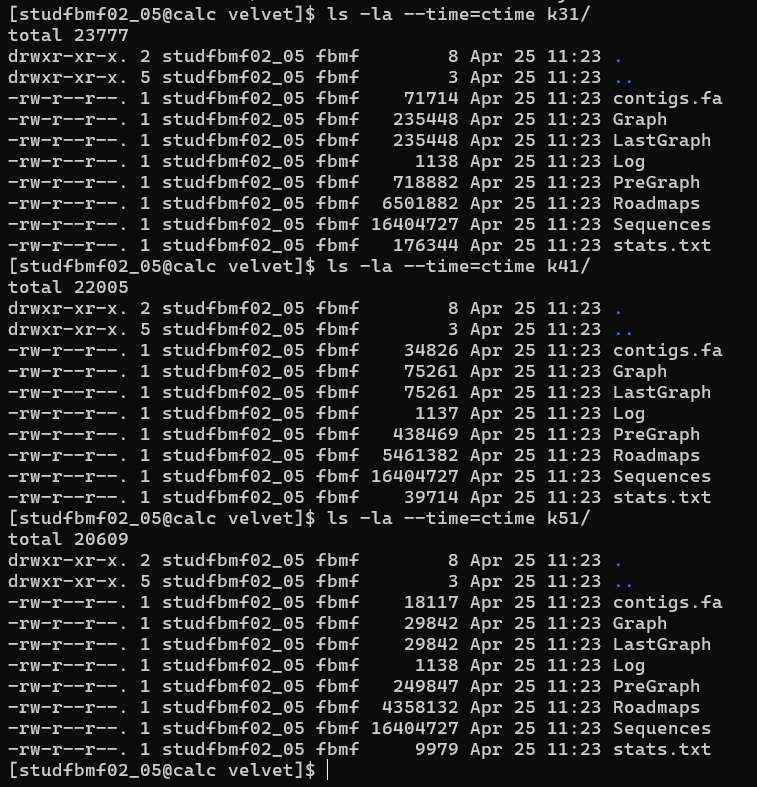

###Часть 2 — Сравнение сборок

Напишем SLURM скрипт `run_spades.sh` для запуска SPAdes сборки и также выведем полученные файлы

In [ ]:
#!/bin/sh
#SBATCH --job-name=JobName        # Job name
#SBATCH --cpus-per-task=1         # Run on a single CPU
#SBATCH --mem=5gb                 # Job memory request
#SBATCH --time=00:10:00           # Time limit hrs:min:sec
#SBATCH --output=JobName.%j.log   # Standard output and error log
#SBATCH --partition=IXG6154-AI-common

python3 /home/STUDY/FBMF/bioinformatics/soft/SPAdes-4.2.0-Linux/bin/spades.py \
    --careful \
    -1 /home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_de_novo/7_S4_L001_R1_001.fastq \
    -2 /home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_de_novo/7_S4_L001_R2_001.fastq \
    -o /home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_assembly_results/spades

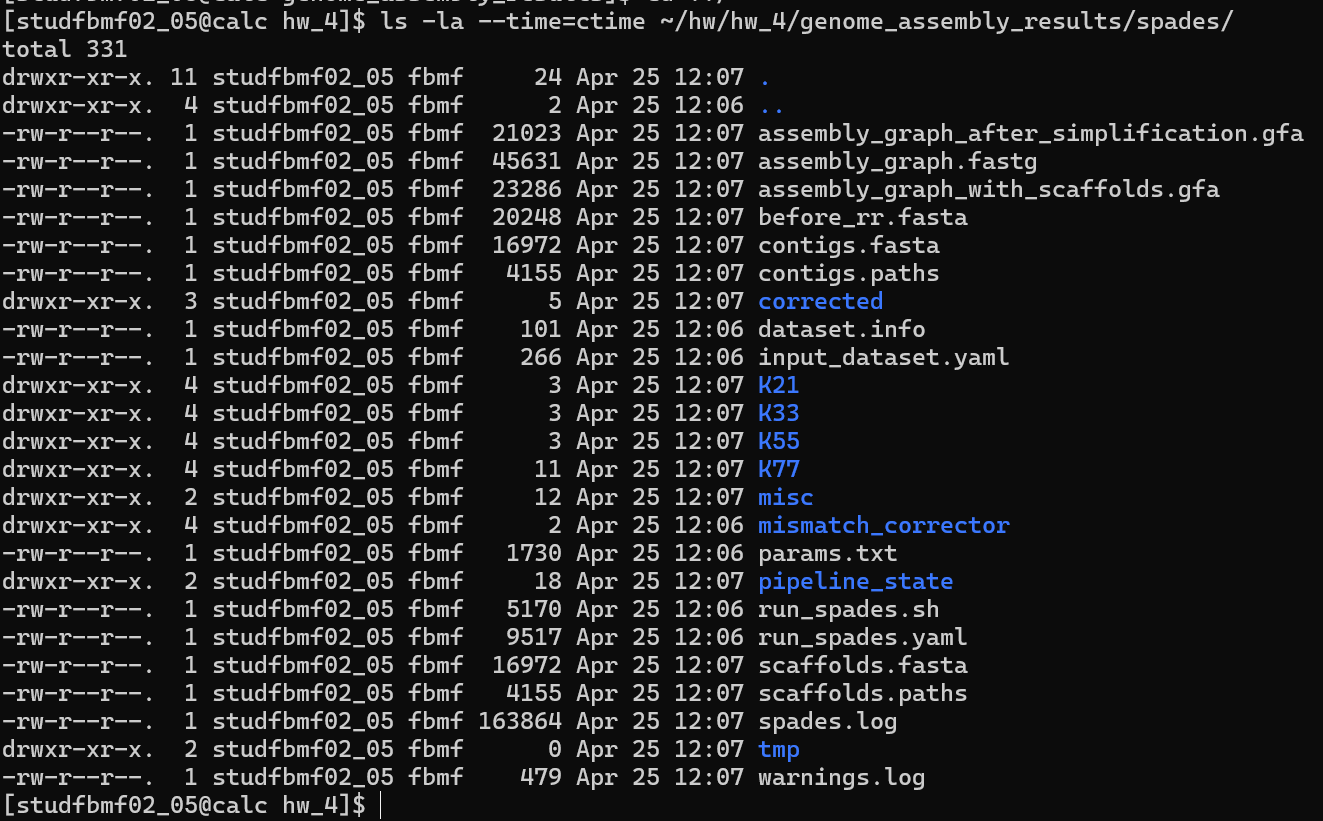

Для наших ридов SPAdes автоматически подобрал k-меры = 21, 33, 55, 77, создал директории с промежуточными результатами для каждого k-мера и занес итоговую сборку в `scaffolds.fasta`

Используя скрипт  `run_quast.sh` сравним два инструмента сборки:

In [ ]:
#!/bin/sh
#SBATCH --job-name=JobName        # Job name
#SBATCH --cpus-per-task=1         # Run on a single CPU
#SBATCH --mem=5gb                 # Job memory request
#SBATCH --time=00:10:00           # Time limit hrs:min:sec
#SBATCH --output=JobName.%j.log   # Standard output and error log
#SBATCH --partition=IXG6154-AI-common

OUTDIR=/home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_assembly_results/quast
VELVET=/home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_assembly_results/velvet
SPADES=/home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_assembly_results/spades

PYTHONPATH=/home/STUDY/FBMF/bioinformatics/soft python3 /home/STUDY/FBMF/bioinformatics/soft/bin/quast.py \
    ${VELVET}/k31/contigs.fa \
    ${VELVET}/k41/contigs.fa \
    ${VELVET}/k51/contigs.fa \
    ${SPADES}/scaffolds.fasta \
    --labels "Velvet_k31,Velvet_k41,Velvet_k51,SPAdes" \
    --min-contig 0 \
    -o ${OUTDIR}

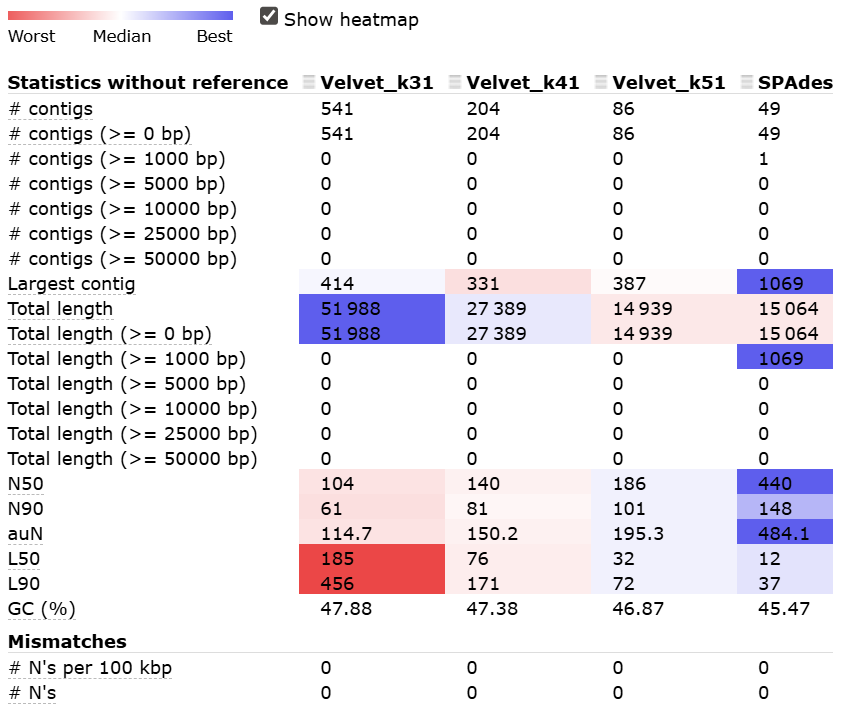

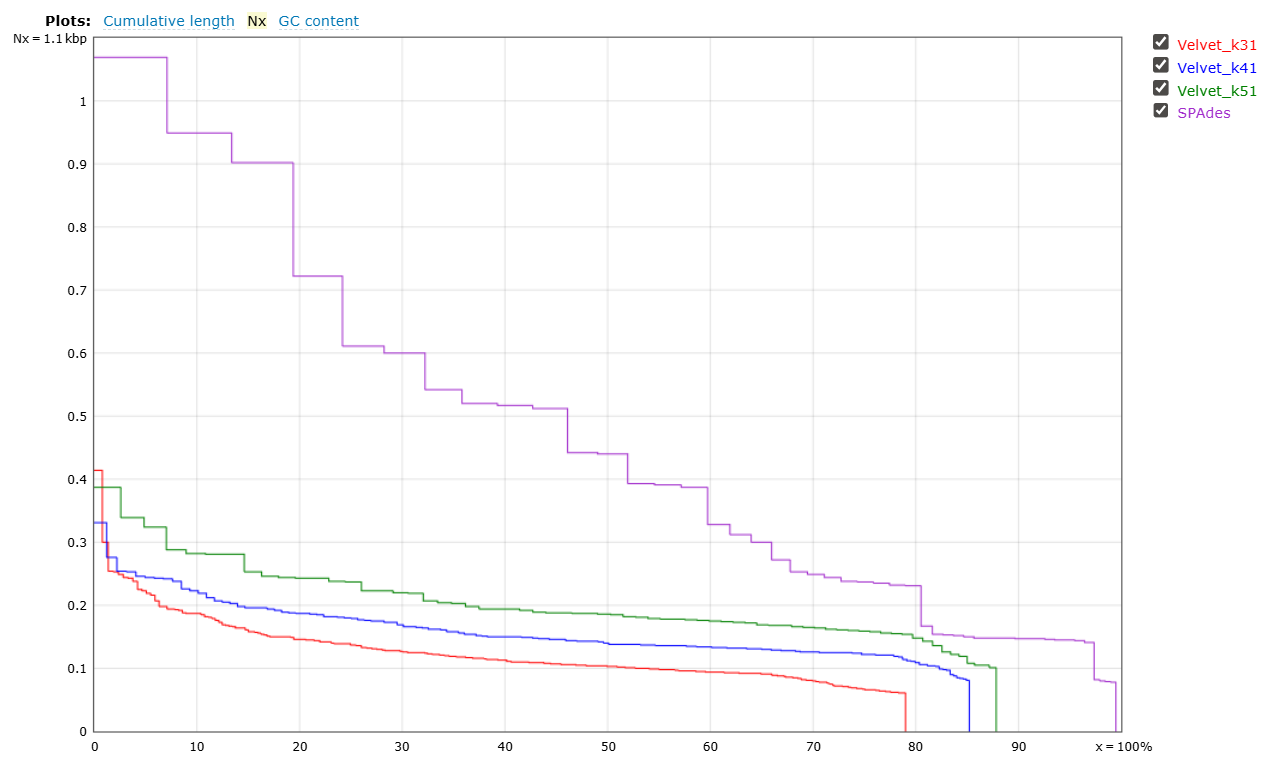

**Выводы:**
*   Velvet с малым k=31 создаёт много коротких контигов и с увеличением k-мера до 51 число контигов падает до 86, N50 вырастает до 186 bp — сборка становится более непрерывной, но при этом суммарная длина уменьшается, тк Velvet оставляет только те части, где есть достаточно надёжная поддержка, и теряет плохо покрытые или неоднозначные фрагменты
*   SPAdes с числом контигов = 49 (приближено к 86 у velvet_k51) даёт принципиально другое качество: N50=440 bp. Не смотря на малую суммарную длину, эта сборка более непрерывная. На графике Nx хорошо видно, что кривая SPAdes идёт значительно выше всех Velvet (уже при небольшом проценте самых длинных контигов она покрывает большую часть общей длины сборки)
*   Velvet проще и быстрее, но качество сборки хуже из-за использования единственного фиксированного k-мера, в то время как SPAdes использует несколько k-меров одновременно (K21, K33, K55, K77), объединяя преимущества малых и больших k-меров

##Часть 3 — Улучшение сборки

###Velvet

По результатам сравнения мы можем оставить k-мер = 51

Для velvetg добавим параметр `-cov_cutoff auto`, который после построения графа удаляет узлы с низким покрытием. Это сделает сборку чище и увеличит длину итоговых контигов

Напишем обновленный скрипт `run_velvet_new.sh` для сборки:

In [ ]:
#!/bin/sh
#SBATCH --job-name=JobName        # Job name
#SBATCH --cpus-per-task=1         # Run on a single CPU
#SBATCH --mem=5gb                 # Job memory request
#SBATCH --time=00:10:00           # Time limit hrs:min:sec
#SBATCH --output=JobName.%j.log   # Standard output and error log
#SBATCH --partition=IXG6154-AI-common

VELVET=/home/STUDY/FBMF/studfbmf02_05/soft/velvet
R1=/home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_de_novo/7_S4_L001_R1_001.fastq
R2=/home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_de_novo/7_S4_L001_R2_001.fastq
OUTDIR=/home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_assembly_results/velvet_new
INS_LENGTH=300

mkdir -p ${OUTDIR}/k51_new
${VELVET}/velveth ${OUTDIR}/k51_new 51 -fastq -shortPaired ${R1} ${R2}
${VELVET}/velvetg ${OUTDIR}/k51_new -ins_length ${INS_LENGTH} -cov_cutoff auto

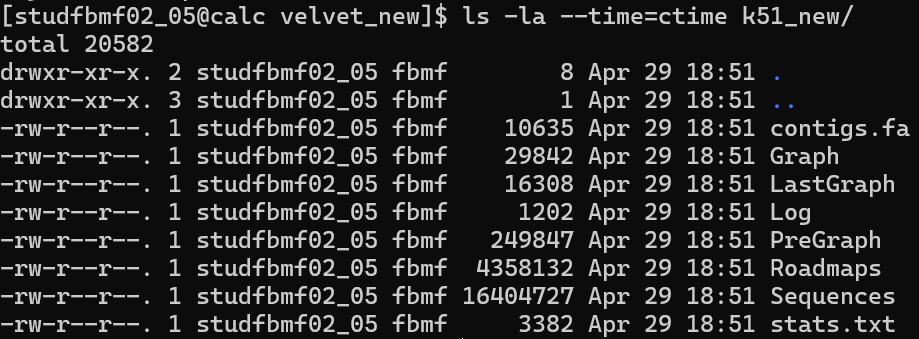

Запустим скрипт сравнения старой и новой сборок `run_quast_velvet.sh`

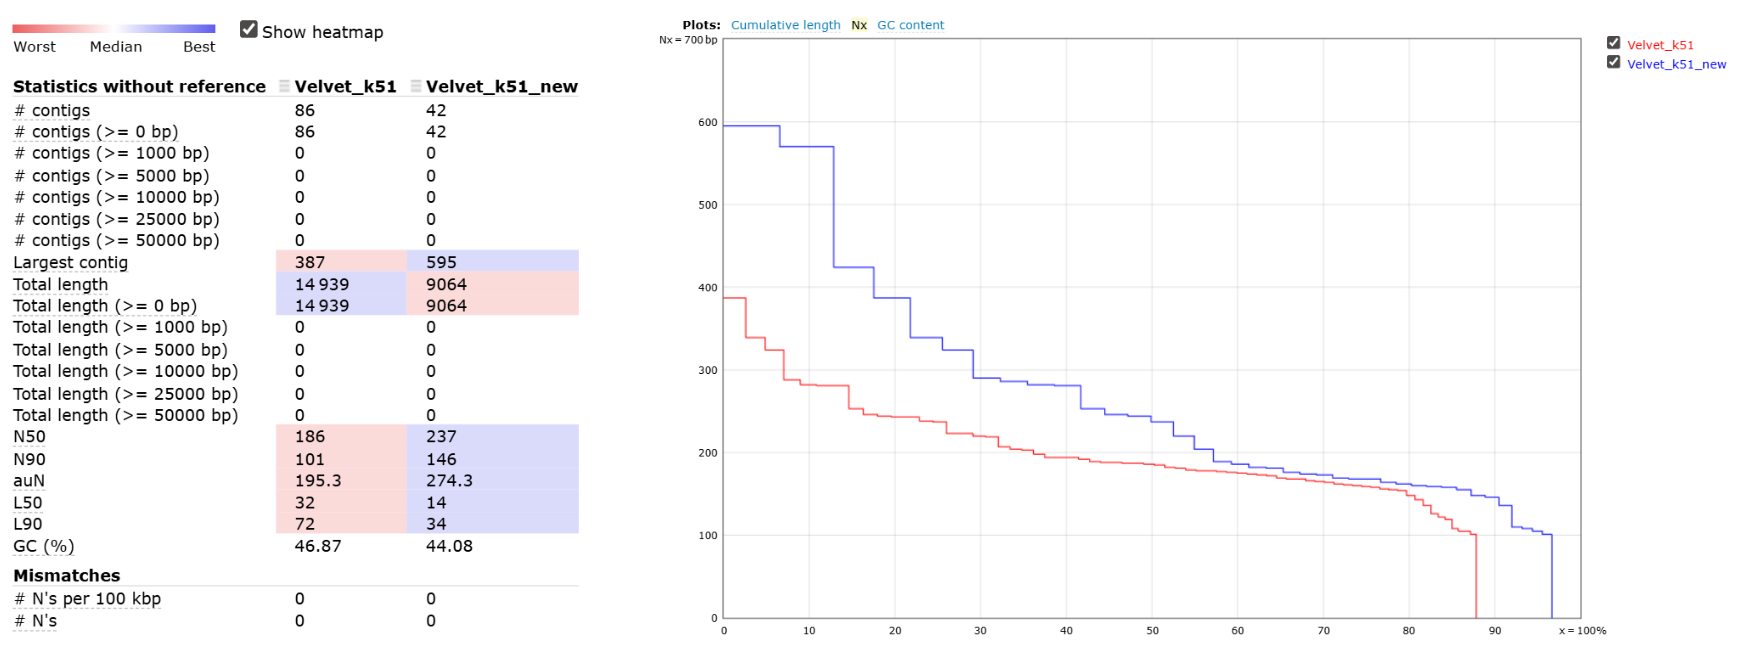

**Выводы:**

*   Мы видим, что сборка стала более непрерывной (N50 повысился) и контиги стали длиннее
*   Суммарная длина уменьшилась, что является ожидаемым результатом, тк мы отфильтровали контиги с низким покрытием


###SPAdes

Можно попробовать вручную задать k-меры по которым будет строиться граф, в нашем случае я решила к автоматически подобранным k (21, 33, 55, 77) добавить еще одно значение k = 99, который лучше будет разрешать повторы тем самым позволит собрать боле длинные контиги

Также добавим фильтр контигов с низким покрытием `--cov-cutoff auto` как мы делали для Velvet

Напишем обновленный скрипт `run_spades_new.sh` для сборки:

In [ ]:
#!/bin/sh
#SBATCH --job-name=JobName        # Job name
#SBATCH --cpus-per-task=8         # Run on a single CPU
#SBATCH --mem=20gb                 # Job memory request
#SBATCH --time=00:30:00           # Time limit hrs:min:sec
#SBATCH --output=JobName.%j.log   # Standard output and error log
#SBATCH --partition=IXG6154-AI-common

python3 /home/STUDY/FBMF/bioinformatics/soft/SPAdes-4.2.0-Linux/bin/spades.py \
    --careful \
    --cov-cutoff auto \
    -k 21,33,55,77,99 \
    -1 /home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_de_novo/7_S4_L001_R1_001.fastq \
    -2 /home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_de_novo/7_S4_L001_R2_001.fastq \
    -o /home/STUDY/FBMF/studfbmf02_05/hw/hw_4/genome_assembly_results/spades_new

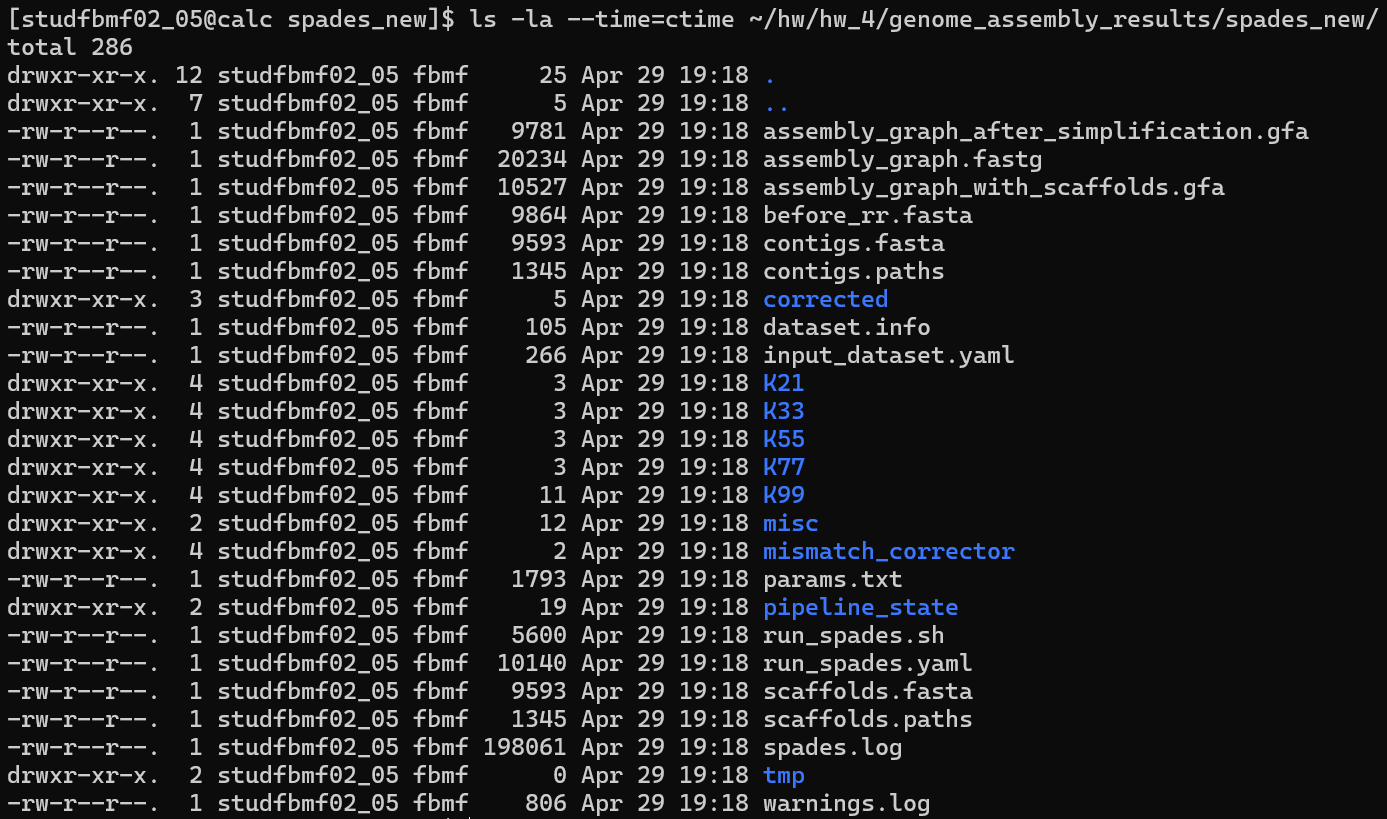

Запустим скрипт сравнения старой и новой сборок `run_quast_spades.sh`

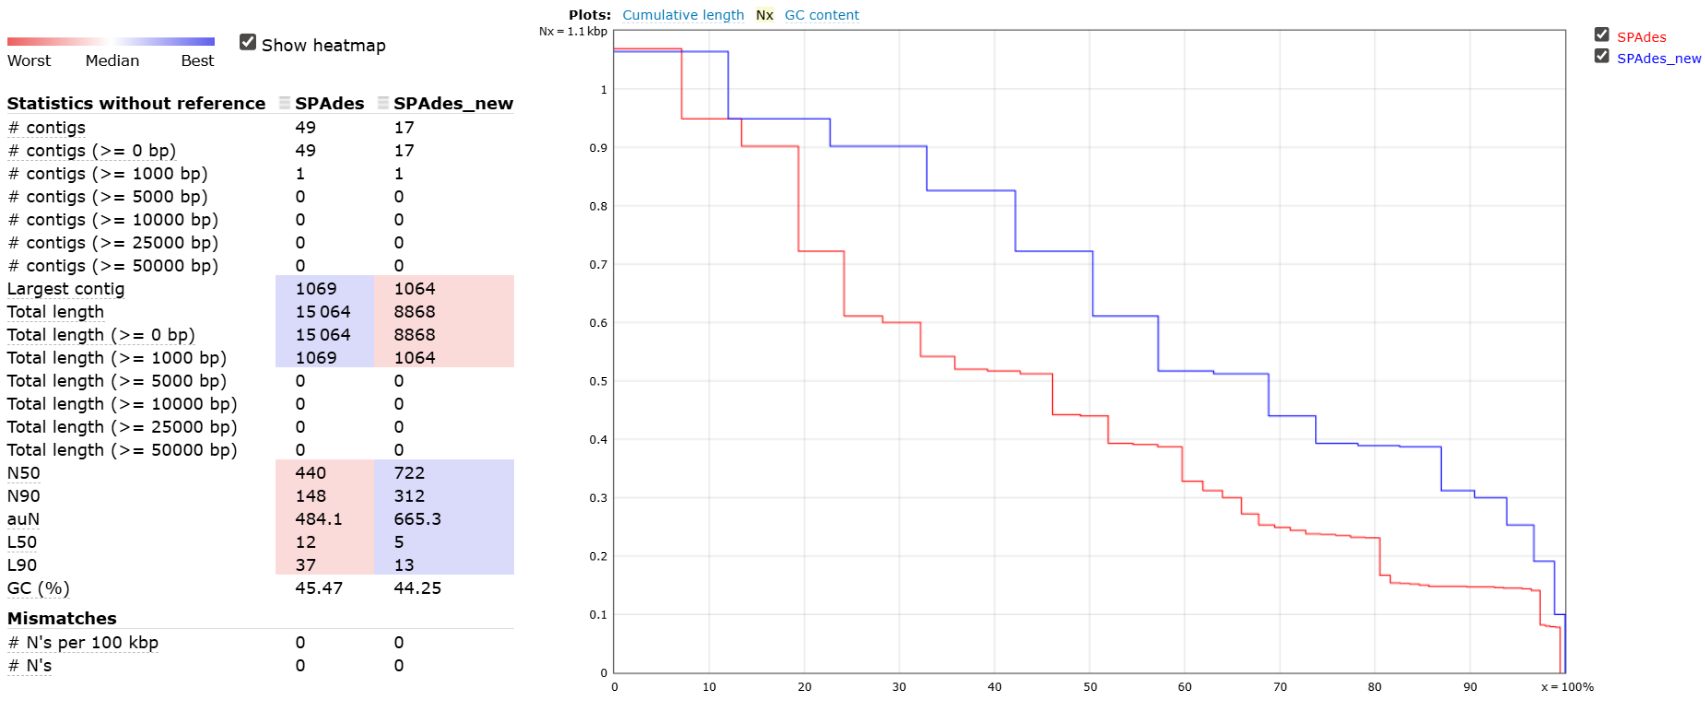

**Выводы:**

*   Также видим рост непрерывности (даже короткие контиги стали вдвое длиннее)
*   L50 сократился,  всего 5 контигов покрывают 50% сборки вместо 12
*   Как и в случае с Velvet, суммарная длина уменьшилась из-за фильтрации